Part A — Data Loading & EDA

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('hospital_data_august_2026.csv', parse_dates=['date'])
df = df.sort_values(["facility_id", "date"]).reset_index(drop=True)

In [30]:
df.shape

(28, 12)

In [31]:
df.head(5)

,date,facility_id,facility_type,lab_tests,ed_arrivals,opd_visits,admissions,discharges,beds_occupied,beds_total,ambulance_calls,is_holiday
0,2026-08-01,GMC-AHM-001,District Hospital,1820,312,1540,78,65,410,500,41,False
1,2026-08-02,GMC-AHM-001,District Hospital,1905,298,1612,82,71,417,500,39,False
2,2026-08-03,GMC-AHM-001,District Hospital,1640,260,980,55,52,388,500,28,True
3,2026-08-04,GMC-AHM-001,District Hospital,1780,290,1410,70,68,392,500,35,False
4,2026-08-05,GMC-AHM-001,District Hospital,1950,320,1680,85,75,420,500,44,False


In [32]:
print(df.dtypes)

date               datetime64[ns]
facility_id                object
facility_type              object
lab_tests                   int64
ed_arrivals                 int64
opd_visits                  int64
admissions                  int64
discharges                  int64
beds_occupied               int64
beds_total                  int64
ambulance_calls             int64
is_holiday                   bool
dtype: object


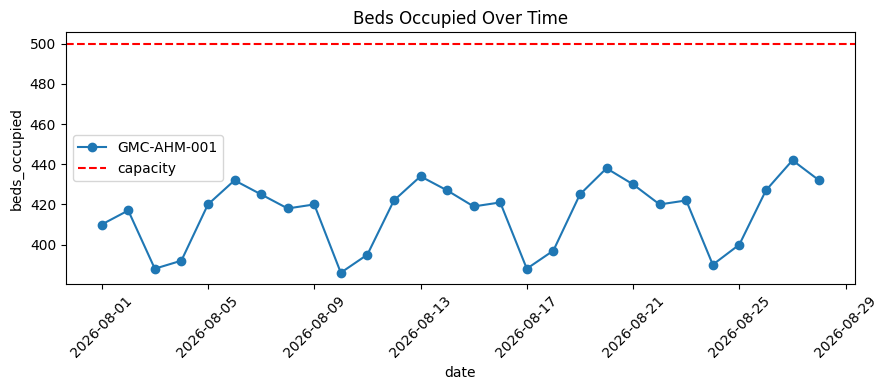

In [33]:
# beds_occupied over time
plt.figure(figsize=(9, 4))
for fac, g in df.groupby("facility_id"):
    plt.plot(g["date"], g["beds_occupied"], marker="o", label=fac)
plt.axhline(df["beds_total"].iloc[0], color="red", linestyle="--", label="capacity")
plt.title("Beds Occupied Over Time")
plt.xlabel("date"); plt.ylabel("beds_occupied")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
print(df.describe())

                      date    lab_tests  ed_arrivals   opd_visits  admissions  \
count                   28    28.000000    28.000000    28.000000    28.00000   
mean   2026-08-14 12:00:00  1857.142857   315.142857  1516.142857    78.25000   
min    2026-08-01 00:00:00  1610.000000   255.000000   950.000000    52.00000   
25%    2026-08-07 18:00:00  1787.500000   299.500000  1457.500000    73.75000   
50%    2026-08-14 12:00:00  1845.000000   315.000000  1575.000000    80.00000   
75%    2026-08-21 06:00:00  1952.500000   332.750000  1672.500000    85.25000   
max    2026-08-28 00:00:00  2080.000000   372.000000  1820.000000    96.00000   
std                    NaN   127.689065    30.731471   249.532706    11.90277   

       discharges  beds_occupied  beds_total  ambulance_calls  
count   28.000000      28.000000        28.0        28.000000  
mean    71.392857     415.607143       500.0        41.107143  
min     50.000000     386.000000       500.0        28.000000  
25%     68.750

In [37]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
date               0
facility_id        0
facility_type      0
lab_tests          0
ed_arrivals        0
opd_visits         0
admissions         0
discharges         0
beds_occupied      0
beds_total         0
ambulance_calls    0
is_holiday         0
dtype: int64


In [38]:
# Weekday / weekend pattern
df["day_of_week"] = df["date"].dt.dayofweek  # Monday=0 ... Sunday=6
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

TARGETS = ["lab_tests", "ed_arrivals", "opd_visits", "beds_occupied", "ambulance_calls"]

weekday_means = df.groupby("day_of_week")[TARGETS].mean().round(1)
weekday_means.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("Mean by day-of-week:")
weekday_means

Mean by day-of-week:


,lab_tests,ed_arrivals,opd_visits,beds_occupied,ambulance_calls
Mon,1637.5,261.8,973.8,388.0,29.2
Tue,1802.5,298.0,1437.5,396.0,37.0
Wed,1972.5,326.2,1687.5,423.5,45.5
Thu,2043.8,363.0,1782.5,436.5,50.8
Fri,1902.5,337.5,1630.0,428.5,43.5
Sat,1787.5,308.0,1522.5,416.8,40.8
Sun,1853.8,311.5,1579.2,420.0,41.0
